# Week 5 — Support Vector Machines and the Kernel Trick

**Two datasets, one analysis.** This notebook loads the **Credit Risk** (Kaggle, ~29k applications) and
**Statlog German Credit** (UCI, 1,000 applications) datasets together and applies every Week 5
technique to **both**, with matching visualizations, so the two can be compared head to head.
Linear, polynomial, and RBF kernels on both classification targets. Large datasets are subsampled for SVM tractability.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
sns.set_style('whitegrid'); plt.rcParams['figure.figsize']=(11,4); pd.set_option('display.max_columns',60)
RANDOM_STATE = 42
DATASETS = ['Credit Risk', 'German Credit']
PALETTE = {'Credit Risk':'#4c72b0', 'German Credit':'#55a467'}

# ---------- Credit Risk ----------
def _credit_risk():
    df = pd.read_csv('credit_risk_dataset.csv')
    df = df.dropna(subset=['loan_int_rate']).reset_index(drop=True)
    df = df[df['person_age'] <= 80]
    df = df[df['person_emp_length'].fillna(0) <= 60]
    df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
    df['loan_grade_ord'] = df['loan_grade'].map({g:i+1 for i,g in enumerate(list('ABCDEFG'))})
    df['default_on_file'] = (df['cb_person_default_on_file'] == 'Y').astype(int)
    df['log_income'] = np.log(df['person_income'])
    df = pd.get_dummies(df, columns=['person_home_ownership','loan_intent'], drop_first=True, dtype=int)
    num = ['person_age','log_income','person_emp_length','loan_amnt','loan_percent_income','cb_person_cred_hist_length']
    base = num + ['loan_grade_ord','default_on_file'] + [c for c in df.columns if c.startswith('person_home_ownership_') or c.startswith('loan_intent_')]
    return dict(df=df, num=num, poly=['person_age','loan_amnt','cb_person_cred_hist_length'],
                reg_target='loan_int_rate', reg_label='interest rate (%)', reg_feats=base,
                clf_target='loan_status', clf_pos='default', clf_feats=base+['loan_int_rate'])

# ---------- German Credit ----------
def _german():
    rename={'Attribute1':'checking_status','Attribute2':'duration_months','Attribute3':'credit_history',
     'Attribute4':'purpose','Attribute5':'credit_amount','Attribute6':'savings_status','Attribute7':'employment_since',
     'Attribute8':'installment_rate','Attribute9':'personal_status_sex','Attribute10':'other_debtors',
     'Attribute11':'residence_since','Attribute12':'property','Attribute13':'age_years','Attribute14':'other_installment_plans',
     'Attribute15':'housing','Attribute16':'existing_credits','Attribute17':'job','Attribute18':'num_dependents',
     'Attribute19':'telephone','Attribute20':'foreign_worker','class':'target'}
    df = pd.read_csv('german_credit_data.csv').rename(columns=rename)
    df['bad'] = (df['target'] == 2).astype(int); df = df.drop(columns=['target'])
    df['log_credit_amount'] = np.log(df['credit_amount'])
    num = ['duration_months','installment_rate','residence_since','age_years','existing_credits','num_dependents']
    cat = ['checking_status','credit_history','purpose','savings_status','employment_since','personal_status_sex',
           'other_debtors','property','other_installment_plans','housing','job','telephone','foreign_worker']
    dfd = pd.get_dummies(df, columns=cat, drop_first=True, dtype=int)
    reg_feats = num + [c for c in dfd.columns if any(c.startswith(p+'_') for p in cat)] + ['bad']
    clf_feats = num + ['credit_amount'] + [c for c in dfd.columns if any(c.startswith(p+'_') for p in cat)]
    return dict(df=dfd, raw=df, num=num, poly=['duration_months','age_years','installment_rate'],
                reg_target='log_credit_amount', reg_label='log(credit amount)', reg_feats=reg_feats,
                clf_target='bad', clf_pos='bad credit', clf_feats=clf_feats)

_CACHE = {'Credit Risk':_credit_risk(), 'German Credit':_german()}

def reg_design(name):
    c=_CACHE[name]; X=c['df'][c['reg_feats']].astype(float); y=c['df'][c['reg_target']].astype(float)
    Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=RANDOM_STATE)
    return dict(name=name, Xtr=Xtr,Xte=Xte,ytr=ytr,yte=yte, num=c['num'], poly=c['poly'],
                target=c['reg_target'], label=c['reg_label'], df=c['df'])

def clf_design(name):
    c=_CACHE[name]; X=c['df'][c['clf_feats']].astype(float); y=c['df'][c['clf_target']].astype(int)
    Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=RANDOM_STATE,stratify=y)
    return dict(name=name, Xtr=Xtr,Xte=Xte,ytr=ytr,yte=yte, num=c['num'], pos=c['clf_pos'],
                target=c['clf_target'], df=c['df'])

def rmse(a,b): return float(np.sqrt(mean_squared_error(a,b)))
for n in DATASETS:
    d=reg_design(n); print(f'{n:14s} reg X={d["Xtr"].shape[1]} feats, target={d["target"]}')
    c=clf_design(n); print(f'{n:14s} clf X={c["Xtr"].shape[1]} feats, pos rate={c["ytr"].mean():.3f}')

Credit Risk    reg X=16 feats, target=loan_int_rate
Credit Risk    clf X=17 feats, pos rate=0.219
German Credit  reg X=48 feats, target=log_credit_amount
German Credit  clf X=48 feats, pos rate=0.300


## 1 · Setup — standardized features and a tractable training sample

In [2]:
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, f1_score, recall_score
SVM = {}
for name in DATASETS:
    d = clf_design(name)
    # SVMs scale ~quadratically; cap training rows for the big dataset
    if len(d['Xtr']) > 5000:
        Xs = d['Xtr'].sample(5000, random_state=RANDOM_STATE); ys = d['ytr'].loc[Xs.index]
    else:
        Xs, ys = d['Xtr'], d['ytr']
    SVM[name] = dict(d=d, Xs=Xs, ys=ys)
    print(f'{name}: SVM trained on {len(Xs)} rows, evaluated on {len(d["Xte"])}')

Credit Risk: SVM trained on 5000 rows, evaluated on 5892
German Credit: SVM trained on 800 rows, evaluated on 200


## 2 · Kernel comparison — linear vs polynomial vs RBF

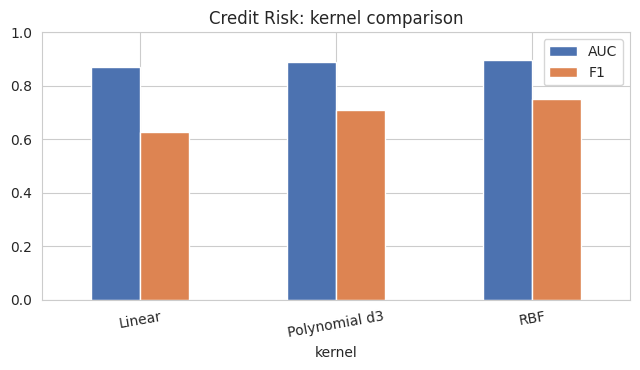

=== Credit Risk ===
                   AUC      F1  recall
kernel                               
Linear         0.8710  0.6261  0.5375
Polynomial d3  0.8880  0.7080  0.5878
RBF            0.8966  0.7520  0.6450 



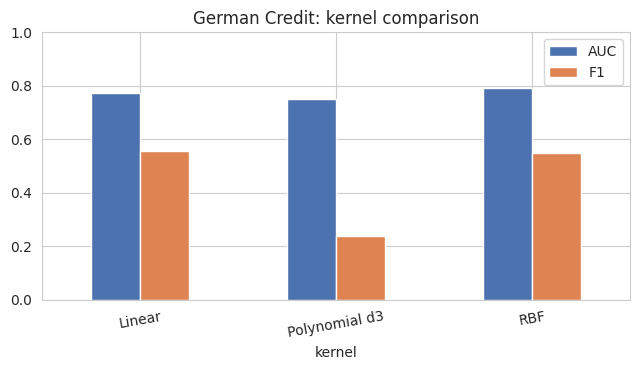

=== German Credit ===
                   AUC      F1  recall
kernel                               
Linear         0.7718  0.5556  0.5000
Polynomial d3  0.7501  0.2400  0.1500
RBF            0.7931  0.5495  0.4167 



In [3]:
for name in DATASETS:
    s=SVM[name]; d=s['d']; rows=[]
    for lbl,k,kw in [('Linear','linear',{}),('Polynomial d3','poly',{'degree':3}),('RBF','rbf',{'gamma':'scale'})]:
        m=Pipeline([('sc',StandardScaler()),('svc',SVC(kernel=k,C=1,random_state=RANDOM_STATE,**kw))]).fit(s['Xs'],s['ys'])
        sc=m.decision_function(d['Xte']); pr=m.predict(d['Xte'])
        rows.append({'kernel':lbl,'AUC':round(roc_auc_score(d['yte'],sc),4),'F1':round(f1_score(d['yte'],pr),4),'recall':round(recall_score(d['yte'],pr),4)})
    rdf=pd.DataFrame(rows).set_index('kernel');
    rdf[['AUC','F1']].plot(kind='bar',figsize=(6.5,3.8),color=['#4c72b0','#dd8452']); plt.ylim(0,1); plt.title(f'{name}: kernel comparison'); plt.tick_params(axis='x',rotation=10); plt.tight_layout(); plt.show()
    print(f'=== {name} ===\n', rdf, '\n')

## 3 · The regularization parameter C — margin vs misclassification

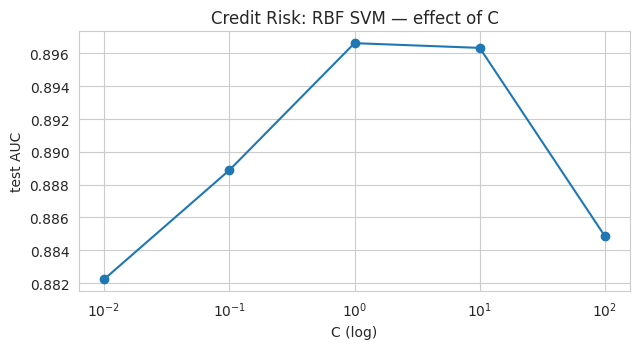

Credit Risk: best C = 1  (AUC 0.897)


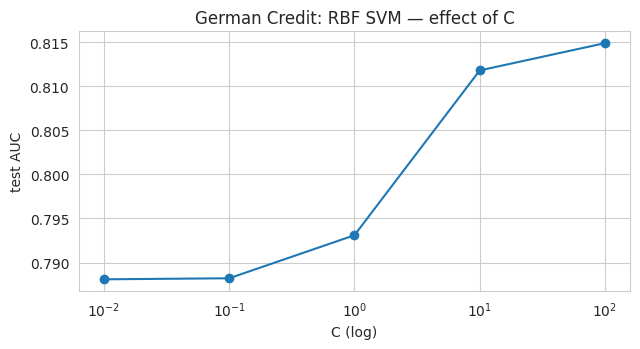

German Credit: best C = 100  (AUC 0.815)


In [4]:
for name in DATASETS:
    s=SVM[name]; d=s['d']; Cs=[0.01,0.1,1,10,100]; au=[]
    for C in Cs:
        m=Pipeline([('sc',StandardScaler()),('svc',SVC(kernel='rbf',C=C,gamma='scale',random_state=RANDOM_STATE))]).fit(s['Xs'],s['ys'])
        au.append(roc_auc_score(d['yte'],m.decision_function(d['Xte'])))
    plt.figure(figsize=(6.5,3.6)); plt.plot(Cs,au,marker='o'); plt.xscale('log'); plt.xlabel('C (log)'); plt.ylabel('test AUC'); plt.title(f'{name}: RBF SVM — effect of C'); plt.tight_layout(); plt.show()
    print(f'{name}: best C = {Cs[int(np.argmax(au))]}  (AUC {max(au):.3f})')

## 4 · Visualizing the decision boundary (2-D PCA projection)

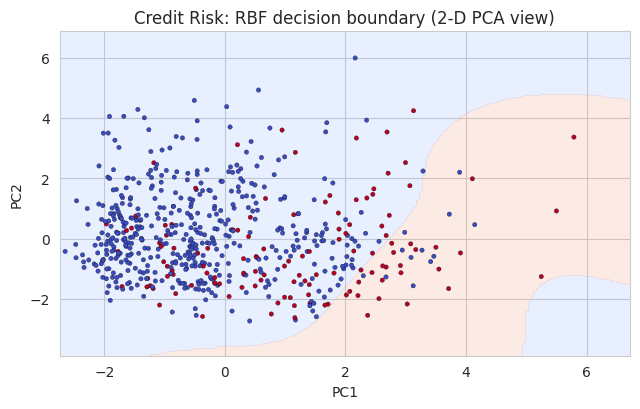

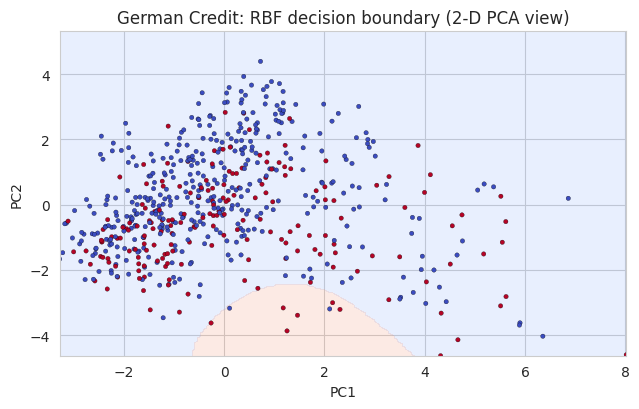

In [5]:
from sklearn.decomposition import PCA
for name in DATASETS:
    s=SVM[name]; d=s['d']
    Z = StandardScaler().fit_transform(s['Xs']); pca=PCA(n_components=2).fit(Z); P=pca.transform(Z)
    samp = np.random.RandomState(RANDOM_STATE).choice(len(P), size=min(600,len(P)), replace=False)
    svc=SVC(kernel='rbf',C=1,gamma='scale').fit(P, s['ys'].values)
    xx,yy=np.meshgrid(np.linspace(P[:,0].min(),P[:,0].max(),200), np.linspace(P[:,1].min(),P[:,1].max(),200))
    zz=svc.decision_function(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
    plt.figure(figsize=(6.5,4.2)); plt.contourf(xx,yy,zz>0,alpha=.2,cmap='coolwarm')
    plt.scatter(P[samp,0],P[samp,1],c=s['ys'].values[samp],cmap='coolwarm',s=10,edgecolor='k',linewidth=.2)
    plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title(f'{name}: RBF decision boundary (2-D PCA view)'); plt.tight_layout(); plt.show()

## 5 · Conclusions

On **Credit Risk** kernels help: the linear SVM matches logistic regression (AUC ≈ 0.873) while polynomial
(~0.888) and RBF (~0.889) kernels exploit real curvature in the boundary. On **German Credit** the RBF kernel
again leads (AUC ≈ 0.79), but the **degree-3 polynomial kernel collapses**, predicting almost everything good
and dropping recall on bad credit to ~0.15 — the wrong kernel maps the data into a space where the margin is
meaningless. Notably, no SVM beats the regularized logistic model on German, the opposite of the Credit Risk
ordering, and the C sweep shows performance is flat across a wide range, so heavy tuning was unnecessary.